Plot EF from various simulations
-

In [1]:
cd ~/Pythons

/home/users/guicha/Pythons


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import itertools

from matplotlib.colors import BoundaryNorm
from global_land_mask import is_land

from KSCALE.read_data.read_data_catalog import load_data_global, load_data_regional
from KSCALE.p_config import regions

/home/users/guicha/.conda/envs/hk25/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
region='Africa'
variable = 'ef'
zoom_low = 7
zoom_high = 8

year = 2020
months = np.arange(1, 12+1, 1)

ts = '1D'  # resampling timescale

lat_range = regions[region][0]
lon_range = regions[region][1]
lat_min = lat_range[0]
lat_max = lat_range[1]
lon_min = lon_range[0]
lon_max = lon_range[1]

In [4]:
data_gal_zlow = load_data_global(resolution='n1280', driving='CoMA9_TBv1p2', zoom=zoom_low, variable=variable,
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
data_ral_zlow = load_data_global(resolution='n2560', driving='RAL3p3', zoom=zoom_low, variable=variable,
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
data_ctc_zlow = load_data_regional(region='CTC', resolution='km4p4', physics='RAL3P3', driving='GAL9', reso_nest='n1280', zoom=zoom_low, variable=variable,
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
data_lam_zlow = load_data_regional(region=region, resolution='km4p4', physics='RAL3P3', driving='GAL9', reso_nest='n1280', zoom=zoom_low, variable=variable,
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)

In [5]:
#~ Ocean masks

lats_zlow = data_gal_zlow.lat.values
lons_zlow = data_gal_zlow.lon.values
lons_zlow_, lats_zlow_ = np.meshgrid(lons_zlow, lats_zlow)
land_mask_zlow = is_land(lats_zlow_, lons_zlow_)


"""data_gal_zlow_land = data_gal_zlow.where(land_mask_zlow)
data_ral_zlow_land = data_ral_zlow.where(land_mask_zlow)
data_lam_zlow_land = data_lam_zlow.where(land_mask_zlow)

data_gal_zhigh_land = data_gal_zhigh.where(land_mask_zhigh)
data_ral_zhigh_land = data_ral_zhigh.where(land_mask_zhigh)"""

'data_gal_zlow_land = data_gal_zlow.where(land_mask_zlow)\ndata_ral_zlow_land = data_ral_zlow.where(land_mask_zlow)\ndata_lam_zlow_land = data_lam_zlow.where(land_mask_zlow)\n\ndata_gal_zhigh_land = data_gal_zhigh.where(land_mask_zhigh)\ndata_ral_zhigh_land = data_ral_zhigh.where(land_mask_zhigh)'

In [6]:
data_gal_zlow_tmean = data_gal_zlow.mean(dim='time')
data_ral_zlow_tmean = data_ral_zlow.mean(dim='time')
diff_ral_zlow = data_gal_zlow_tmean - data_ral_zlow_tmean

data_ctc_zlow_tmean = data_ctc_zlow.mean(dim='time')
diff_ctc_zlow = data_gal_zlow_tmean - data_ctc_zlow_tmean

data_lam_zlow_tmean = data_lam_zlow.mean(dim='time')
diff_gal_lam_zlow = data_gal_zlow_tmean - data_lam_zlow_tmean
diff_ral_lam_zlow = data_ral_zlow_tmean - data_lam_zlow_tmean
#diff_gals = data_gal_zhigh_tmean - data_gal_zlow_tmean
#diff_rals = data_ral_zhigh_tmean - data_ral_zlow_tmean

"""data_gal_zlow_smean = data_gal_zlow.mean(dim=['lat', 'lon'])
data_ral_zlow_smean = data_ral_zlow.mean(dim=['lat', 'lon'])
data_lam_zlow_smean = data_lam_zlow.mean(dim=['lat', 'lon'])
data_gal_zhigh_smean = data_gal_zhigh.mean(dim=['lat', 'lon'])
data_ral_zhigh_smean = data_ral_zhigh.mean(dim=['lat', 'lon'])"""

"data_gal_zlow_smean = data_gal_zlow.mean(dim=['lat', 'lon'])\ndata_ral_zlow_smean = data_ral_zlow.mean(dim=['lat', 'lon'])\ndata_lam_zlow_smean = data_lam_zlow.mean(dim=['lat', 'lon'])\ndata_gal_zhigh_smean = data_gal_zhigh.mean(dim=['lat', 'lon'])\ndata_ral_zhigh_smean = data_ral_zhigh.mean(dim=['lat', 'lon'])"

In [7]:
#~ Mask ocean

data_gal_zlow_tmean = data_gal_zlow_tmean.where(land_mask_zlow)
data_ral_zlow_tmean = data_ral_zlow_tmean.where(land_mask_zlow)
data_ctc_zlow_tmean = data_ctc_zlow_tmean.where(land_mask_zlow)
data_lam_zlow_tmean = data_lam_zlow_tmean.where(land_mask_zlow)

diff_ral_zlow = diff_ral_zlow.where(land_mask_zlow)
diff_ctc_zlow = diff_ctc_zlow.where(land_mask_zlow)
diff_gal_lam_zlow = diff_gal_lam_zlow.where(land_mask_zlow)
diff_ral_lam_zlow = diff_ral_lam_zlow.where(land_mask_zlow)

In [8]:
data_min = min(abs(data_ral_zlow_tmean.min()), abs(data_ral_zlow_tmean.min()), abs(data_ctc_zlow_tmean.min()), abs(data_lam_zlow_tmean.min())).values
data_max = max(abs(data_gal_zlow_tmean.max()), abs(data_ral_zlow_tmean.max()), abs(data_ctc_zlow_tmean.max()), abs(data_lam_zlow_tmean.max())).values
data_min, data_max

(array(0.00021125, dtype=float32), array(0.94399136, dtype=float32))

In [9]:
diff_min = min(diff_ral_zlow.min(), diff_ctc_zlow.min(), diff_gal_lam_zlow.min(), diff_ral_lam_zlow.min()).values
diff_max = min(abs(diff_ral_zlow.max()), diff_ctc_zlow.max(), abs(diff_gal_lam_zlow.max()), abs(diff_ral_lam_zlow.max())).values
diff_lim = max(abs(diff_min), abs(diff_max))
diff_lim

np.float32(0.58420324)

In [10]:
imths = data_gal_zlow.groupby('time.month').groups
months_all = {'DJF': [1, 2, 12],
                'MAM': [3, 4, 5],
                'JJA': [6, 7, 8],
                'SON': [9, 10, 11]}

/tmp/ipykernel_4164/2396742966.py:75: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 17 Axes> than <Figure size 640x480 with 16 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(p, norm=norm, cmap=cmap, ax=ax[:], orientation='horizontal', label='EF [$-$]', shrink=0.5, pad=0.1)


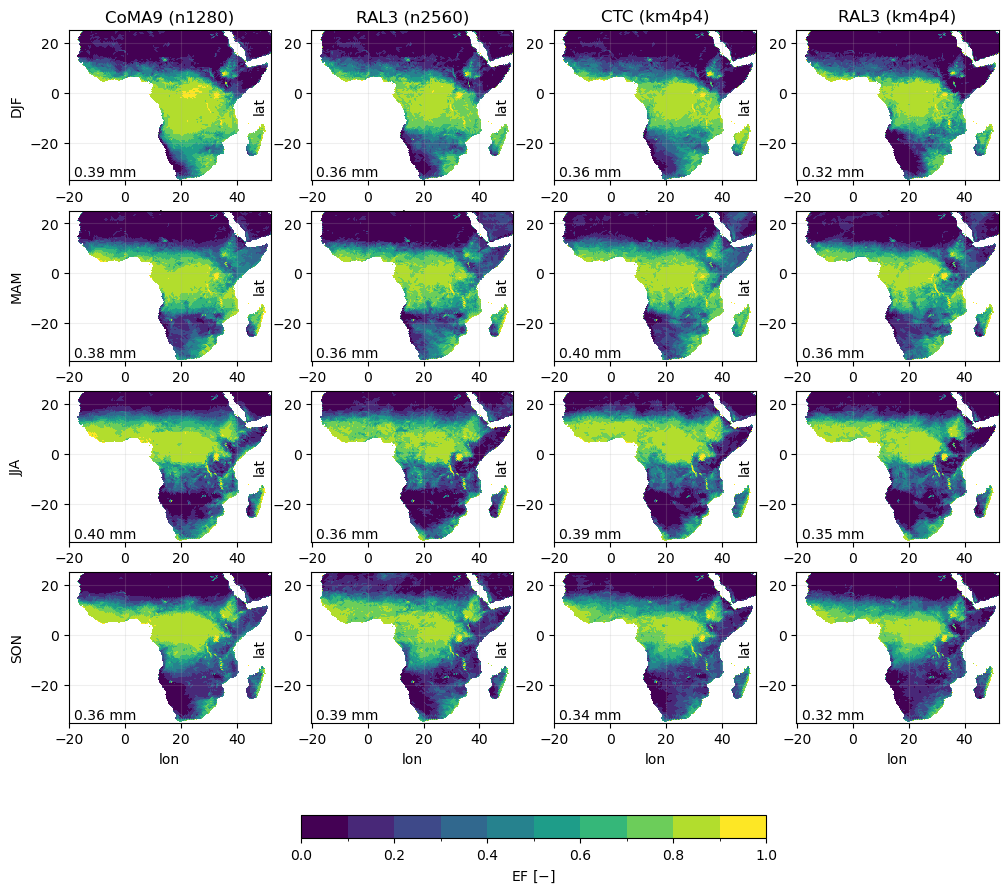

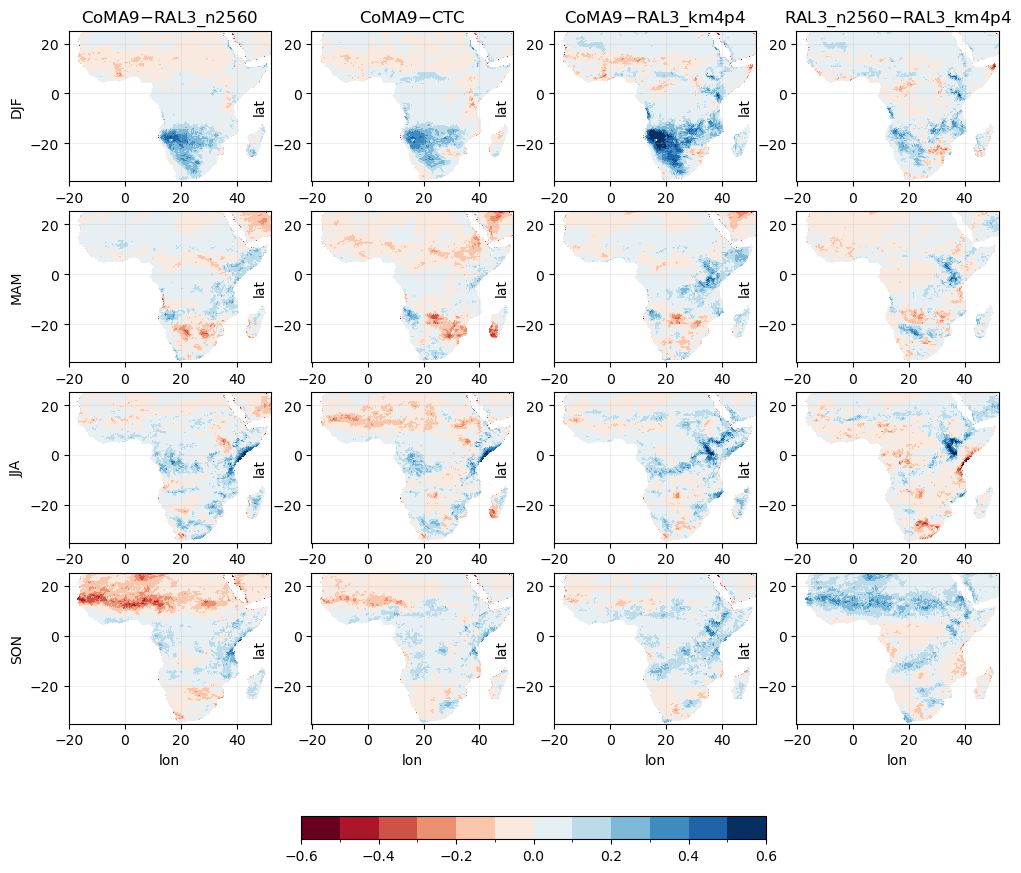

In [17]:
cmap = plt.get_cmap('viridis')
cmap_diff = plt.get_cmap('RdBu')
bounds = np.linspace(0., 1., 11)
norm = BoundaryNorm(bounds, cmap.N)
bounds_diff = np.linspace(-0.6, 0.6, 13)
norm_diff = BoundaryNorm(bounds_diff, cmap.N)


fig, ax = plt.subplots(ncols=4, nrows=4)
fig_diff, ax_diff = plt.subplots(ncols=4, nrows=4)

for i, (seas, mths) in enumerate(months_all.items()):
    lmonths = [imths[m] for m in mths]
    lmonths = list(itertools.chain(*lmonths))

    ax_ = ax[i]
    ax_diff_ = ax_diff[i]

    data_gal_zlow_ms = data_gal_zlow.isel(time=lmonths).mean(dim='time').where(land_mask_zlow)
    data_ral_zlow_ms = data_ral_zlow.isel(time=lmonths).mean(dim='time').where(land_mask_zlow)
    data_ctc_zlow_ms = data_ctc_zlow.isel(time=lmonths).mean(dim='time').where(land_mask_zlow)
    data_lam_zlow_ms = data_lam_zlow.isel(time=lmonths).mean(dim='time').where(land_mask_zlow)

    diff_ral_zlow_ms = data_gal_zlow_ms - data_ral_zlow_ms
    diff_ctc_zlow_ms = data_gal_zlow_ms - data_ctc_zlow_ms
    diff_gal_lam_zlow_ms = data_gal_zlow_ms - data_lam_zlow_ms
    diff_ral_lam_zlow_ms = data_ral_zlow_ms - data_lam_zlow_ms

    p = data_gal_zlow_ms.plot(ax=ax_[0], norm=norm, cmap=cmap, add_colorbar=False)
    data_ral_zlow_ms.plot(ax=ax_[1], norm=norm, cmap=cmap, add_colorbar=False)
    data_ctc_zlow_ms.plot(ax=ax_[2], norm=norm, cmap=cmap, add_colorbar=False)
    data_lam_zlow_ms.plot(ax=ax_[3], norm=norm, cmap=cmap, add_colorbar=False)

    p_diff = diff_ral_zlow_ms.plot(ax=ax_diff_[0], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)
    diff_ctc_zlow_ms.plot(ax=ax_diff_[1], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)
    diff_gal_lam_zlow_ms.plot(ax=ax_diff_[2], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)
    diff_ral_lam_zlow_ms.plot(ax=ax_diff_[3], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)

    ax_[0].text(0.025, 0.025, '%.2f mm'%data_gal_zlow_ms.mean(), transform=ax_[0].transAxes)
    ax_[1].text(0.025, 0.025, '%.2f mm'%data_ral_zlow_ms.mean(), transform=ax_[1].transAxes)
    ax_[2].text(0.025, 0.025, '%.2f mm'%data_ctc_zlow_ms.mean(), transform=ax_[2].transAxes)
    ax_[3].text(0.025, 0.025, '%.2f mm'%data_lam_zlow_ms.mean(), transform=ax_[3].transAxes)

    ax_[0].set_ylabel(seas)
    ax_[0].grid(True, alpha=0.2)
    ax_[1].grid(True, alpha=0.2)
    ax_[2].grid(True, alpha=0.2)
    ax_[3].grid(True, alpha=0.2)

    ax_diff_[0].set_ylabel(seas)
    ax_diff_[0].grid(True, alpha=0.2)
    ax_diff_[1].grid(True, alpha=0.2)
    ax_diff_[2].grid(True, alpha=0.2)
    ax_diff_[3].grid(True, alpha=0.2)

    if i == 0:
        ax_[0].set_title('CoMA9 (n1280)')
        ax_[1].set_title('RAL3 (n2560)')
        ax_[2].set_title('CTC (km4p4)')
        ax_[3].set_title('RAL3 (km4p4)')
        ax_diff_[0].set_title('CoMA9$-$RAL3_n2560')
        ax_diff_[1].set_title('CoMA9$-$CTC')
        ax_diff_[2].set_title('CoMA9$-$RAL3_km4p4')
        ax_diff_[3].set_title('RAL3_n2560$-$RAL3_km4p4')
    else:
        ax_[0].set_title('')
        ax_[1].set_title('')
        ax_[2].set_title('')
        ax_[3].set_title('')
        ax_diff_[0].set_title('')
        ax_diff_[1].set_title('')
        ax_diff_[2].set_title('')
        ax_diff_[3].set_title('')

cb = plt.colorbar(p, norm=norm, cmap=cmap, ax=ax[:], orientation='horizontal', label='EF [$-$]', shrink=0.5, pad=0.1)
cb_diff = plt.colorbar(p_diff, norm=norm_diff, cmap=cmap_diff, ax=ax_diff[:], orientation='horizontal', shrink=0.5, pad=0.1)

fig.set_size_inches(12., 12.)
fig_diff.set_size_inches(12., 12.)

fig.show()
fig_diff.show()

In [12]:
data_gal_zlow_waf = data_gal_zlow.sel(lat=slice(5, 20), lon=slice(-20, 20)).mean(dim=['lat', 'lon']).rolling(time=15, center=True).mean()
data_ral_zlow_waf = data_ral_zlow.sel(lat=slice(5, 20), lon=slice(-20, 20)).mean(dim=['lat', 'lon']).rolling(time=15, center=True).mean()
data_ctc_zlow_waf = data_ctc_zlow.sel(lat=slice(5, 20), lon=slice(-20, 20)).mean(dim=['lat', 'lon']).rolling(time=15, center=True).mean()
data_lam_zlow_waf = data_lam_zlow.sel(lat=slice(5, 20), lon=slice(-20, 20)).mean(dim=['lat', 'lon']).rolling(time=15, center=True).mean()

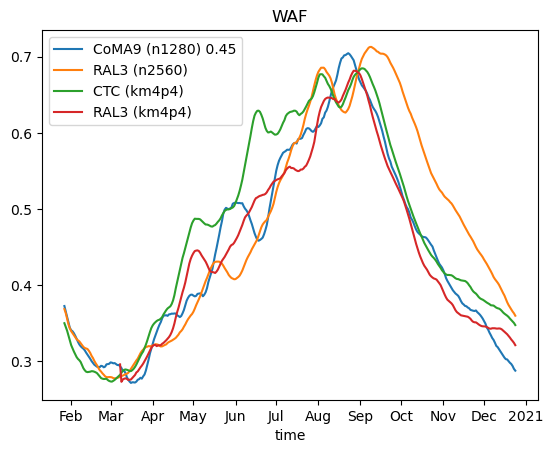

In [13]:
data_gal_zlow_waf.plot(label='CoMA9 (n1280) %.2f'%data_gal_zlow_waf.mean())
data_ral_zlow_waf.plot(label='RAL3 (n2560)')
data_ctc_zlow_waf.plot(label='CTC (km4p4)')
data_lam_zlow_waf.plot(label='RAL3 (km4p4)')

plt.title('WAF')
plt.legend()

In [14]:
sys.exit()

SystemExit: 

/home/users/guicha/.conda/envs/hk25/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3678: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


BACKUP

In [ ]:
bounds = np.linspace(0, 1, 11)
bounds_diff = np.linspace(-0.6, 0.6, 13)
cmap = plt.get_cmap('viridis')
cmap_diff = plt.get_cmap('RdBu')

norm = BoundaryNorm(bounds, cmap.N, extend='max')
norm_diff = BoundaryNorm(bounds_diff, cmap.N, extend='max')


fig, ax = plt.subplots(ncols=4, nrows=4)

plt.subplots_adjust(hspace=0.2)

p = data_gal_zlow_tmean.plot(ax=ax[0][0], norm=norm, cmap=cmap, add_colorbar=False)
data_ral_zlow_tmean.plot(ax=ax[0][1], norm=norm, cmap=cmap, add_colorbar=False)
p_diff = diff_zlow.plot(ax=ax[0][2], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)

data_gal_zhigh_tmean.plot(ax=ax[1][0], norm=norm, cmap=cmap, add_colorbar=False)
data_ral_zhigh_tmean.plot(ax=ax[1][1], norm=norm, cmap=cmap, add_colorbar=False)
diff_zhigh.plot(ax=ax[1][2], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)

data_gal_zlow_tmean.plot(ax=ax[2][0], norm=norm, cmap=cmap, add_colorbar=False)
data_lam_zlow_tmean.plot(ax=ax[2][1], norm=norm, cmap=cmap, add_colorbar=False)
diff_gal_lam_zlow.plot(ax=ax[2][2], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)

data_ral_zlow_tmean.plot(ax=ax[3][0], norm=norm, cmap=cmap, add_colorbar=False)
data_lam_zlow_tmean.plot(ax=ax[3][1], norm=norm, cmap=cmap, add_colorbar=False)
diff_ral_lam_zlow.plot(ax=ax[3][2], norm=norm_diff, cmap=cmap_diff, add_colorbar=False)

#p_diff2 = diff_gals.plot(ax=ax[2][0], vmin=-1., vmax=1., cmap=cmap_diff, add_colorbar=False)
#diff_rals.plot(ax=ax[2][1], vmin=-1., vmax=1., cmap=cmap_diff, add_colorbar=False)

cb = plt.colorbar(p, orientation='horizontal', ax=ax[:,0:2], shrink=0.65, label='pr [mm]', pad=0.1)
cb_diff = plt.colorbar(p_diff, orientation='horizontal', ax=ax[:,2], pad=0.1)
#cb_diff2 = plt.colorbar(p_diff2, orientation='horizontal', ax=ax[:,0:2])

"""ax0_ = ax[0].inset_axes([0.075, 0.1, 0.3, 0.3])
sb.kdeplot(data_gal_tmean.values.flatten(), ax=ax0_)
ax0_.set_ylabel('')
ax0_.set_yticklabels([])
ax1_ = ax[1].inset_axes([0.075, 0.1, 0.3, 0.3])
sb.kdeplot(data_ral_tmean.values.flatten(), ax=ax1_)
ax1_.set_ylabel('')
ax1_.set_yticklabels([])"""
ax02_ = ax[0][2].inset_axes([0.075, 0.2, 0.3, 0.3])
sb.kdeplot(diff_zlow.values.flatten(), ax=ax02_)
#ax02_.set_xlim(-0.6, 0.6)
ax02_.set_ylabel('')
ax02_.set_yticklabels([])
ax12_ = ax[1][2].inset_axes([0.075, 0.2, 0.3, 0.3])
sb.kdeplot(diff_zhigh.values.flatten(), ax=ax12_)
#ax12_.set_xlim(-0.6, 0.6)
ax12_.set_ylabel('')
ax12_.set_yticklabels([])
ax22_ = ax[2][2].inset_axes([0.075, 0.2, 0.3, 0.3])
sb.kdeplot(diff_gal_lam_zlow.values.flatten(), ax=ax22_)
#ax12_.set_xlim(-0.6, 0.6)
ax22_.set_ylabel('')
ax22_.set_yticklabels([])
ax32_ = ax[3][2].inset_axes([0.075, 0.2, 0.3, 0.3])
sb.kdeplot(diff_ral_lam_zlow.values.flatten(), ax=ax32_)
#ax12_.set_xlim(-0.6, 0.6)
ax32_.set_ylabel('')
ax32_.set_yticklabels([])

ax[0][0].set_xticklabels([])
ax[0][0].set_xlabel('')
ax[0][1].set_xticklabels([])
ax[0][1].set_xlabel('')
ax[0][1].set_yticklabels([])
ax[0][1].set_ylabel('')
ax[0][2].set_xticklabels([])
ax[0][2].set_xlabel('')
ax[0][2].set_yticklabels([])
ax[0][2].set_ylabel('')
ax[1][0].set_xticklabels([])
ax[1][0].set_xlabel('')
ax[1][1].set_xticklabels([])
ax[1][1].set_xlabel('')
ax[1][1].set_yticklabels([])
ax[1][1].set_ylabel('')
ax[1][2].set_xticklabels([])
ax[1][2].set_xlabel('')
ax[1][2].set_yticklabels([])
ax[1][2].set_ylabel('')
ax[2][0].set_xticklabels([])
ax[2][0].set_xlabel('')
ax[2][1].set_xticklabels([])
ax[2][1].set_xlabel('')
ax[2][1].set_yticklabels([])
ax[2][1].set_ylabel('')
ax[2][2].set_xticklabels([])
ax[2][2].set_xlabel('')
ax[2][2].set_yticklabels([])
ax[2][2].set_ylabel('')
ax[3][1].set_yticklabels([])
ax[3][1].set_ylabel('')
ax[3][2].set_yticklabels([])
ax[3][2].set_ylabel('')

ax[0][0].set_title('CoMA9_TBv1p2 $-$ z%i'%zoom_low)
ax[0][1].set_title('RAL3p3_n2560 $-$ z%i'%zoom_low)
ax[0][2].set_title('CoMA9_TBv1p2-RAL3 $-$ z%i'%zoom_low)
ax[1][0].set_title('CoMA9_TBv1p2 $-$ z%i'%zoom_high)
ax[1][1].set_title('RAL3p3_n2560 $-$ z%i'%zoom_high)
ax[1][2].set_title('CoMA9_TBv1p2-RAL3 $-$ z%i'%zoom_high)
ax[2][0].set_title('CoMA9_TBv1p2 $-$ z%i'%zoom_low)
ax[2][1].set_title('RAL3p3_km4p4 $-$ z%i'%zoom_low)
ax[2][2].set_title('CoMA9_TBv1p2-RAL3_km4p4 $-$ z%i'%zoom_low)
ax[3][0].set_title('RAL3_n2560 $-$ z%i'%zoom_low)
ax[3][1].set_title('RAL3p3_km4p4 $-$ z%i'%zoom_low)
ax[3][2].set_title('RAL3_n2560-RAL3_km4p4 $-$ z%i'%zoom_low)

fig.set_size_inches(10., 12.)